# Итоговое задание: продуктовая аналитика маркетплейса Olist

**Цель исследования:** оценить возвращаемость клиентов, наличие product/market fit, определить ключевые метрики продукта, выбрать гипотезу через ICE и сформулировать метрики для A/B-теста.

**Используемые данные:**
- `olist_customers_dataset.csv` — клиенты;
- `olist_orders_dataset.csv` — заказы;
- `olist_order_items_dataset.csv` — товарные позиции в заказах.

**Ключевая методология:** для retention и продуктовых метрик успешной покупкой считаем заказ со статусом `delivered`, так как это наиболее чистый признак того, что клиент получил ценность от маркетплейса.

## 0. Импорты, настройки и загрузка данных

In [1]:
# import warnings
# warnings.filterwarnings('ignore') #скроем алерты для красоты

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.4f}'.format)

sns.set_theme(style='whitegrid', font_scale=1.05)

DATA_PATH = '.'

In [3]:
customers = pd.read_csv(f'{DATA_PATH}/olist_customers_dataset.csv')
orders = pd.read_csv(f'{DATA_PATH}/olist_orders_dataset.csv')
items_d = pd.read_csv(f'{DATA_PATH}/olist_order_items_dataset.csv')

# Приводим даты к datetime
order_date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in order_date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

items_d['shipping_limit_date'] = pd.to_datetime(items_d['shipping_limit_date'], errors='coerce')

print('customers:', customers.shape)
print('orders:', orders.shape)
print('items_d:', items_d.shape)

display(customers.head(3))
display(orders.head(3))
display(items_d.head(3))

customers: (99441, 5)
orders: (99441, 8)
items_d: (112650, 7)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9000,13.2900
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9000,19.9300
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0000,17.8700


## 0.1. Базовая проверка данных

Проверим ключи, статусы заказов и период наблюдения. Это нужно, чтобы корректно выбрать базу для retention и продуктовых метрик.

In [9]:
print('customer_id уникален в customers:', customers['customer_id'].is_unique)
print('order_id уникален в orders:', orders['order_id'].is_unique)

print('Период данных по дате оформления заказа:')
print('min:', orders['order_purchase_timestamp'].min())
print('max:', orders['order_purchase_timestamp'].max())

status_summary = (
    orders['order_status']
    .value_counts()
    .rename_axis('order_status')
    .reset_index(name='orders')
)
status_summary['share'] = status_summary['orders'] / status_summary['orders'].sum()

display(status_summary)

customer_id уникален в customers: True
order_id уникален в orders: True
Период данных по дате оформления заказа:
min: 2016-09-04 21:15:19
max: 2018-10-17 17:30:18


,order_status,orders,share
0,delivered,96478,0.9702
1,shipped,1107,0.0111
2,canceled,625,0.0063
3,unavailable,609,0.0061
4,invoiced,314,0.0032
5,processing,301,0.0030
6,created,5,0.0001
7,approved,2,0.0000


In [10]:
# Основная витрина заказов: добавляем customer_unique_id
orders_customers = orders.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)

# Успешные покупки: доставленные заказы
delivered = orders_customers[orders_customers['order_status'] == 'delivered'].copy()

print('Всего заказов:', orders_customers['order_id'].nunique())
print('Доставленных заказов:', delivered['order_id'].nunique())
print('Доля доставленных заказов:', f"{delivered['order_id'].nunique() / orders_customers['order_id'].nunique():.2%}")

Всего заказов: 99441
Доставленных заказов: 96478
Доля доставленных заказов: 97.02%


---
# Задача 1. Месячный retention в оформление заказа

Нужно построить месячный retention с помощью когортного анализа:
- определить, какие заказы учитываются в retention;
- построить retention matrix;
- найти медианный retention 1-го месяца;
- найти когорту с максимальным retention на 3-й месяц;
- визуализировать результат.

В retention учитываем только `delivered`-заказы. Это консервативный, но наиболее бизнесово чистый вариант: клиент не просто оформил заказ, а получил товар.

In [11]:
# Месяц заказа
delivered['order_month'] = (
    delivered['order_purchase_timestamp']
    .dt.to_period('M')
    .dt.to_timestamp() #2017-06-15 14:32:10 → 2017-06 → 2017-06-01 00:00:00
)

# Когорта = месяц первой успешной покупки клиента
first_purchase = (
    delivered
    .groupby('customer_unique_id', as_index=False)
    .agg(cohort_month=('order_month', 'min'))
)

delivered = delivered.merge(first_purchase, on='customer_unique_id', how='left')

# Номер месяца жизни когорты: 0 — месяц первой покупки, 1 — следующий месяц и т.д.
delivered['period_number'] = (
    (delivered['order_month'].dt.year - delivered['cohort_month'].dt.year) * 12
    + (delivered['order_month'].dt.month - delivered['cohort_month'].dt.month)
)

display(delivered[['customer_unique_id', 'order_id', 'order_month', 'cohort_month', 'period_number']].head())

,customer_unique_id,order_id,order_month,cohort_month,period_number
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-01,2017-09-01,1
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-01,2018-07-01,0
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-01,2018-08-01,0
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-01,2017-11-01,0
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-01,2018-02-01,0


In [12]:
cohort_counts = (
    delivered
    .groupby(['cohort_month', 'period_number'])['customer_unique_id']
    .nunique()
    .reset_index(name='customers')
)

cohort_pivot = cohort_counts.pivot_table(
    index='cohort_month',
    columns='period_number',
    values='customers'
)

cohort_sizes = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_sizes, axis=0)

# Основные ответы по заданию считаем по всем когортам без фильтрации,
# потому что в формулировке задания нет условия исключать маленькие когорты.
median_retention_1 = retention[1].median()
best_cohort_month_3 = retention[3].idxmax()
best_retention_month_3 = retention.loc[best_cohort_month_3, 3]

print(f'Медианный retention 1-го месяца: {median_retention_1:.2%}')
print(f'Когорта с самым высоким retention на 3-й месяц: {best_cohort_month_3:%Y-%m}')
print(f'Retention этой когорты на 3-й месяц: {best_retention_month_3:.2%}')

summary_task_1 = pd.DataFrame({
    'cohort_size': cohort_sizes,
    'retention_1_month': retention[1],
    'retention_3_month': retention[3]
})

display(summary_task_1)

Медианный retention 1-го месяца: 0.51%
Когорта с самым высоким retention на 3-й месяц: 2017-06
Retention этой когорты на 3-й месяц: 0.43%


,cohort_size,retention_1_month,retention_3_month
cohort_month,,,
2016-09-01,1.0000,NaN,NaN
2016-10-01,262.0000,NaN,NaN
2016-12-01,1.0000,1.0000,NaN
2017-01-01,717.0000,0.0028,0.0014
2017-02-01,"1,628.0000",0.0018,0.0012
2017-03-01,"2,503.0000",0.0044,0.0040
2017-04-01,"2,256.0000",0.0062,0.0018
2017-05-01,"3,451.0000",0.0046,0.0029
2017-06-01,"3,037.0000",0.0049,0.0043


### Визуализация retention

0-й месяц всегда равен 100%, потому что это месяц первой покупки. Если оставить его на heatmap, цветовая шкала станет неинформативной: реальные значения retention после первой покупки находятся ниже 1%.

Для читаемой визуализации:
- скрываем 0-й месяц;
- показываем значения в процентах;
- ограничиваем цветовую шкалу диапазоном 0–1%;
- ранние когорты 2016 года не исключаем из расчётов, но в графике можно отдельно сфокусироваться на основном периоде с 2017 года.

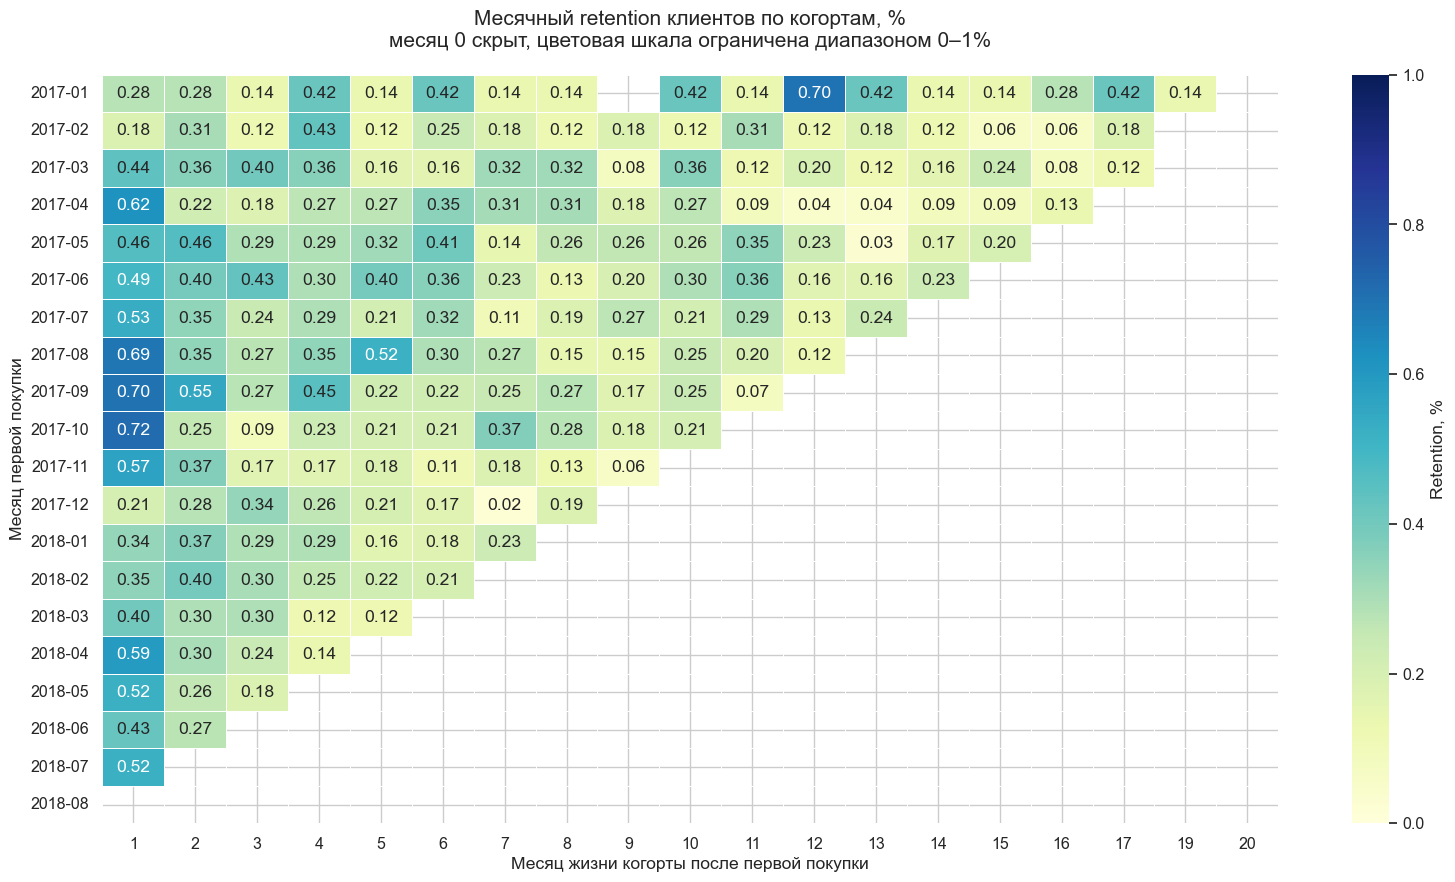

In [17]:
retention_for_plot = retention.drop(columns=0).copy()
retention_for_plot.index = pd.to_datetime(retention_for_plot.index).strftime('%Y-%m')

# Для читаемой финальной картинки фокусируемся на основном периоде с 2017 года
retention_for_plot_main = retention_for_plot.loc['2017-01':]

plt.figure(figsize=(16, 9))

sns.heatmap(
    retention_for_plot_main * 100,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Retention, %'},
    vmin=0,
    vmax=1
)

plt.title(
    'Месячный retention клиентов по когортам, %\n'
    'месяц 0 скрыт, цветовая шкала ограничена диапазоном 0–1%',
    fontsize=15,
    pad=20
)
plt.xlabel('Месяц жизни когорты после первой покупки')
plt.ylabel('Месяц первой покупки')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Вывод по задаче 1.** Retention после первой покупки крайне низкий: медианное значение 1-го месяца находится ниже 1%. Это означает, что маркетплейс в основном привлекает разовых покупателей, а повторные покупки случаются редко.

---
# Задача 2. Product/market fit

PMF через когортный анализ можно оценивать по форме retention curve:
- если retention падает, но затем выходит на устойчивое плато, это признак ядра пользователей, которым продукт регулярно нужен;
- если retention остаётся около нуля и не формирует заметного плато, PMF по повторному использованию не подтверждается.

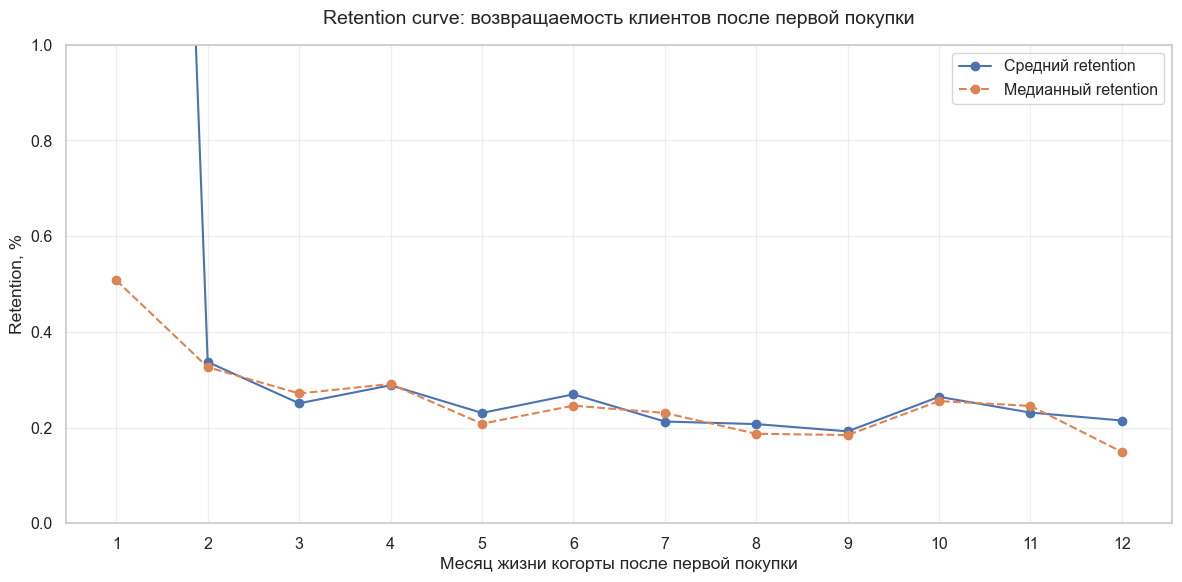

In [24]:
# Для PMF-графика берём первые 12 месяцев жизни когорты:
# дальний хвост нестабилен, потому что до него доживает мало когорт (хвост до 1%)
retention_pmf = retention.drop(columns=0).loc[:, 1:12]

mean_retention_by_month = retention_pmf.mean() * 100
median_retention_by_month = retention_pmf.median() * 100

plt.figure(figsize=(12, 6))

plt.plot(
    mean_retention_by_month.index,
    mean_retention_by_month.values,
    marker='o',
    label='Средний retention'
)

plt.plot(
    median_retention_by_month.index,
    median_retention_by_month.values,
    marker='o',
    linestyle='--',
    label='Медианный retention'
)

plt.title('Retention curve: возвращаемость клиентов после первой покупки', fontsize=14, pad=15)
plt.xlabel('Месяц жизни когорты после первой покупки')
plt.ylabel('Retention, %')
plt.xticks(mean_retention_by_month.index)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

,period_number,median_retention_percent
0,1,0.5075
1,2,0.3261
2,3,0.2711


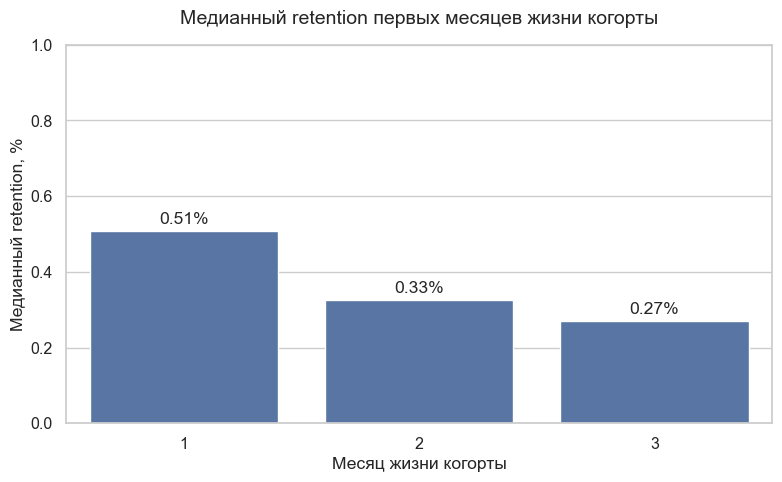

In [25]:
#retention первых месяцев жизни когорты

pmf_summary = pd.DataFrame({
    'period_number': [1, 2, 3],
    'median_retention_percent': [
        retention[1].median() * 100,
        retention[2].median() * 100,
        retention[3].median() * 100
    ]
})

display(pmf_summary)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=pmf_summary,
    x='period_number',
    y='median_retention_percent'
)

plt.title('Медианный retention первых месяцев жизни когорты', fontsize=14, pad=15)
plt.xlabel('Месяц жизни когорты')
plt.ylabel('Медианный retention, %')
plt.ylim(0, max(1, pmf_summary['median_retention_percent'].max() * 1.5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()

**Вывод по задаче 2.** Наличие устойчивого product/market fit по повторным заказам не подтверждается. Retention после первой покупки находится ниже 1%, а значит продукт пока не формирует регулярный сценарий использования.

Масштабирование такого маркетплейса рискованно: рост будет зависеть в основном от постоянного привлечения новых покупателей, а не от удержания существующих. В ближайшее время продукту стоит сфокусироваться на удержании: найти категории и сегменты с более высоким repeat rate, изучить клиентский опыт и протестировать механики повторных покупок.

---
# Задача 3. Пять ключевых продуктовых метрик

Для максимизации прибыли маркетплейсу стоит сфокусироваться на пяти метриках:

1. **GMV / Revenue** — отражает рост объёма продаж маркетплейса.
2. **Monthly Buyers** — показывает размер аудитории, которая получает ценность через успешную покупку.
3. **Conversion to First Purchase** — отражает заинтересованность новых клиентов. В текущем датасете её нельзя посчитать, потому что нет визитов, регистраций и событий до заказа.
4. **Repeat Purchase Rate** — отражает возвращаемость и вовлечённость клиентов в продолжение использования продукта.
5. **ARPPU / Revenue per Buyer** — показывает денежное выражение вовлечённости клиента.

Далее визуализируем 1-ю, 2-ю, 4-ю и 5-ю метрики в месячной гранулярности.

In [66]:
# GMV на уровне заказа: сумма price по товарным позициям.
# freight_value считаем отдельно, но в GMV не включаем.
order_gmv = (
    items_d
    .groupby('order_id', as_index=False)
    .agg(
        gmv=('price', 'sum'),
        freight=('freight_value', 'sum')
    )
)

# Витрина для продуктовых метрик: только доставленные заказы
metrics_df = delivered.merge(order_gmv, on='order_id', how='left')

# Флаг повторного покупателя в конкретном месяце
metrics_df['is_repeat_buyer'] = metrics_df['order_month'] > metrics_df['cohort_month']

# Агрегируем до уровня клиент-месяц, чтобы корректно считать покупателей
monthly_customer_activity = (
    metrics_df
    .groupby(['order_month', 'customer_unique_id'], as_index=False)
    .agg(
        gmv=('gmv', 'sum'),
        is_repeat_buyer=('is_repeat_buyer', 'max')
    )
)

monthly_metrics = (
    monthly_customer_activity
    .groupby('order_month', as_index=False)
    .agg(
        gmv=('gmv', 'sum'),
        monthly_buyers=('customer_unique_id', 'nunique'),
        repeat_buyers=('is_repeat_buyer', 'sum')
    )
)

monthly_metrics['repeat_purchase_rate'] = monthly_metrics['repeat_buyers'] / monthly_metrics['monthly_buyers']
monthly_metrics['arppu'] = monthly_metrics['gmv'] / monthly_metrics['monthly_buyers']

# Убираем неполные/аномальные края для финальной визуализации
monthly_metrics_plot = monthly_metrics[
    (monthly_metrics['order_month'] >= '2017-01-01') &
    (monthly_metrics['order_month'] <= '2018-08-01')
].copy()

display(monthly_metrics_plot)

,order_month,gmv,monthly_buyers,repeat_buyers,repeat_purchase_rate,arppu
3,2017-01-01,"111,798.3600",718,1,0.0014,155.7080
4,2017-02-01,"234,223.4000",1630,2,0.0012,143.6953
5,2017-03-01,"359,198.8500",2508,5,0.0020,143.2212
6,2017-04-01,"340,669.6800",2274,18,0.0079,149.8108
7,2017-05-01,"489,338.2500",3479,28,0.0080,140.6549
8,2017-06-01,"421,923.3700",3076,39,0.0127,137.1662
9,2017-07-01,"481,604.5200",3802,50,0.0132,126.6714
10,2017-08-01,"554,699.7000",4114,57,0.0139,134.8322
11,2017-09-01,"607,399.6700",4083,79,0.0193,148.7631
12,2017-10-01,"648,247.6500",4417,89,0.0201,146.7620


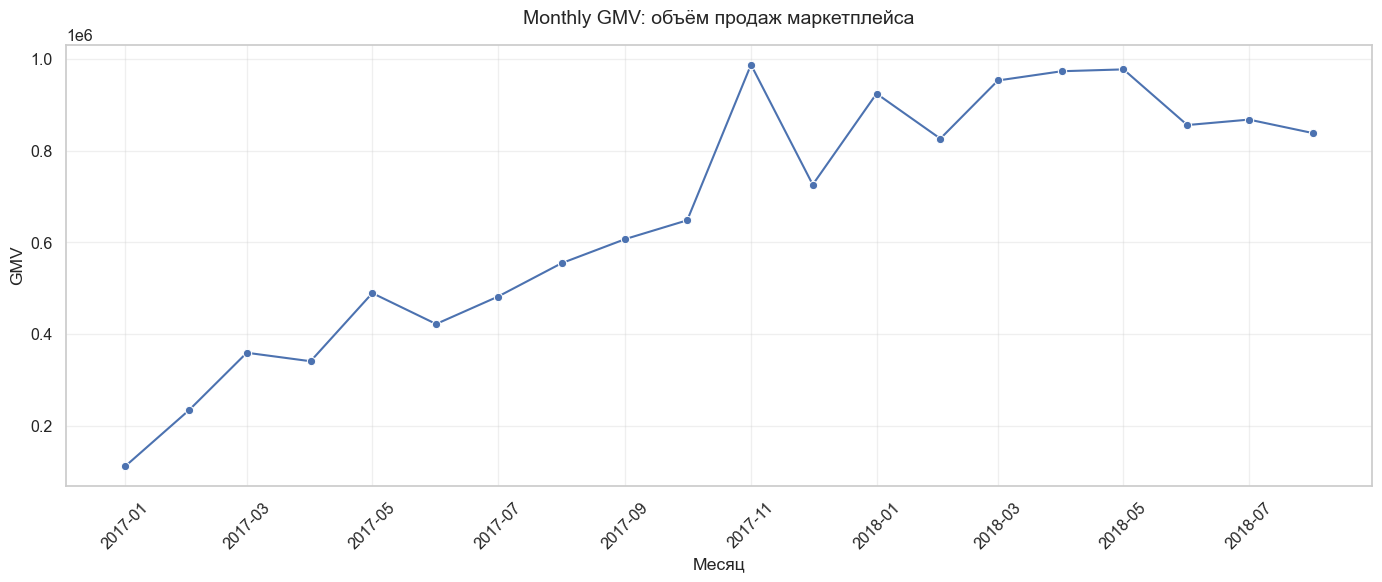

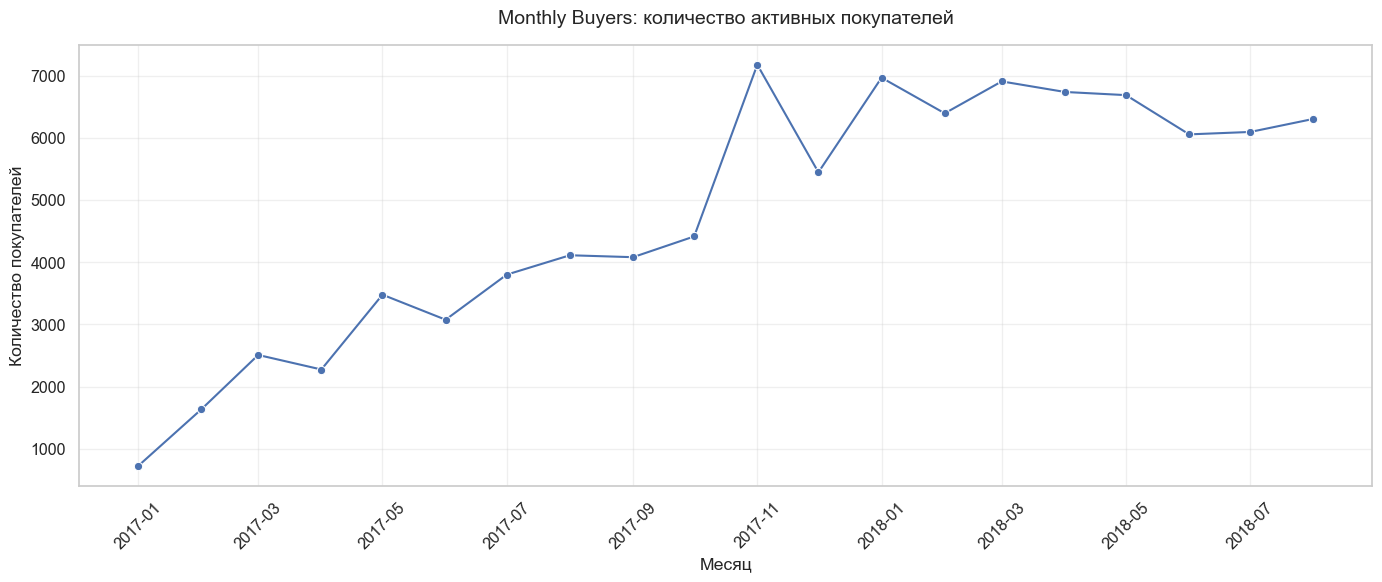

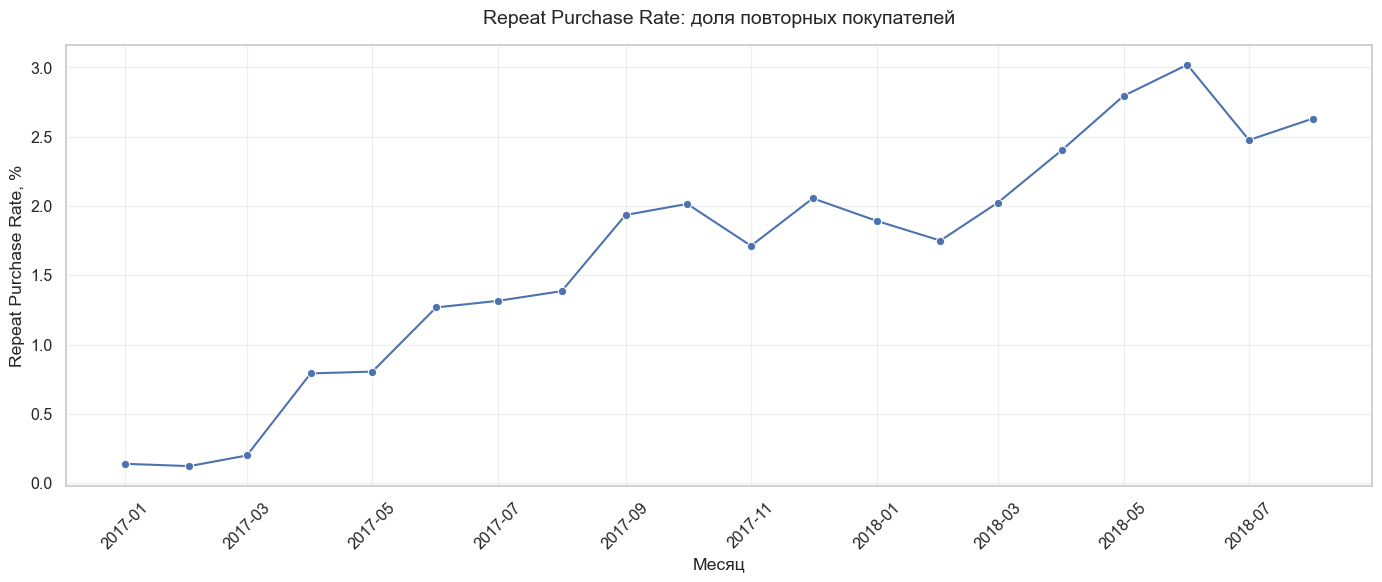

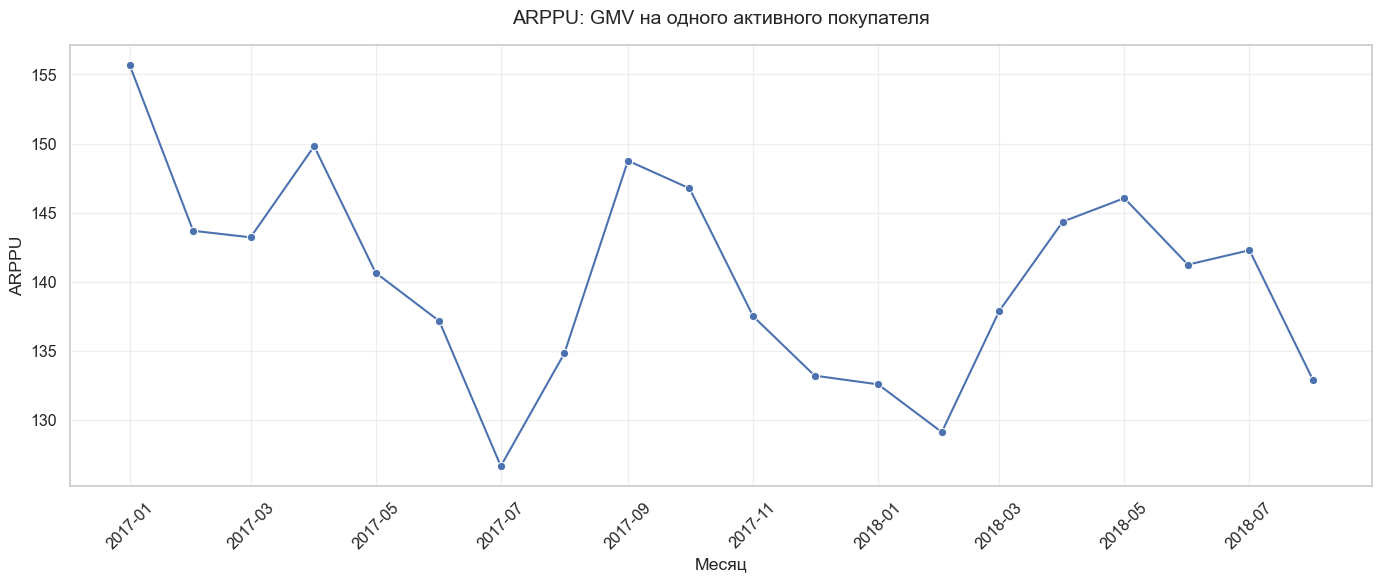

In [28]:
def plot_monthly_line(data, y, title, ylabel, percent=False):
    plt.figure(figsize=(14, 6))
    plot_data = data.copy()
    y_values = plot_data[y] * 100 if percent else plot_data[y]

    sns.lineplot(
        x=plot_data['order_month'],
        y=y_values,
        marker='o'
    )

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Месяц')
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_monthly_line(
    monthly_metrics_plot,
    'gmv',
    'Monthly GMV: объём продаж маркетплейса',
    'GMV'
)

plot_monthly_line(
    monthly_metrics_plot,
    'monthly_buyers',
    'Monthly Buyers: количество активных покупателей',
    'Количество покупателей'
)

plot_monthly_line(
    monthly_metrics_plot,
    'repeat_purchase_rate',
    'Repeat Purchase Rate: доля повторных покупателей',
    'Repeat Purchase Rate, %',
    percent=True
)

plot_monthly_line(
    monthly_metrics_plot,
    'arppu',
    'ARPPU: GMV на одного активного покупателя',
    'ARPPU'
)

**Вывод по задаче 3.** GMV и количество покупателей показывают масштаб маркетплейса, но низкий Repeat Purchase Rate подтверждает проблему удержания. Поэтому продукту важно не только привлекать новых покупателей, но и увеличивать повторные покупки. Без роста возвращаемости бизнес будет зависеть от постоянных затрат на привлечение нового спроса.

---
# Задача 4. Выбор гипотезы через ICE

Команда сформулировала три гипотезы. Нужно рассчитать Impact по данным **начиная с июня 2017 года** и выбрать гипотезу с максимальным ICE.

Используем формулу:

**ICE = Impact × Confidence × Ease**

Для гипотез, связанных с повторным заказом, конверсию в повторный заказ принимаем равной медианному retention 1-го месяца из задачи 1.

In [29]:
# Данные начиная с июня 2017 года
orders_customers['order_month'] = (
    orders_customers['order_purchase_timestamp']
    .dt.to_period('M')
    .dt.to_timestamp()
)

data_from_june_2017 = orders_customers[
    orders_customers['order_month'] >= '2017-06-01'
].copy()

median_retention_1_month = retention[1].median()

print(f'Медианный retention 1-го месяца из задачи 1: {median_retention_1_month:.6f}')
print(f'В процентах: {median_retention_1_month * 100:.2f}%')
print('Период для Impact:', data_from_june_2017['order_month'].min(), '—', data_from_june_2017['order_month'].max())

Медианный retention 1-го месяца из задачи 1: 0.005075
В процентах: 0.51%
Период для Impact: 2017-06-01 00:00:00 — 2018-10-01 00:00:00


In [30]:
# Гипотеза 1: исправить баг в процессинге и избавиться от отмен
impact_h1_metric = data_from_june_2017.loc[
    data_from_june_2017['order_status'] == 'canceled',
    'order_id'
].nunique()

# Гипотеза 2: сократить время до отгрузки и снизить задержки доставки
# Считаем клиентов, у которых доставленный заказ приехал позже обещанной даты.
delivered_from_june = data_from_june_2017[
    data_from_june_2017['order_status'] == 'delivered'
].copy()

delivered_from_june['is_late'] = (
    delivered_from_june['order_delivered_customer_date'] >
    delivered_from_june['order_estimated_delivery_date']
)

late_customers = delivered_from_june.loc[
    delivered_from_june['is_late'],
    'customer_unique_id'
].nunique()

impact_h2_metric = late_customers * median_retention_1_month

# Гипотеза 3: новый способ оплаты для клиентов, которые раньше не повторяли покупку.
# Берём клиентов с доставленными заказами с июня 2017,
# у которых за весь период наблюдения только один доставленный заказ.
delivered_all = orders_customers[orders_customers['order_status'] == 'delivered'].copy()

orders_per_customer = (
    delivered_all
    .groupby('customer_unique_id', as_index=False)
    .agg(total_delivered_orders=('order_id', 'nunique'))
)

delivered_customers_from_june = data_from_june_2017.loc[
    data_from_june_2017['order_status'] == 'delivered',
    ['customer_unique_id']
].drop_duplicates()

customers_orders_from_june = delivered_customers_from_june.merge(
    orders_per_customer,
    on='customer_unique_id',
    how='left'
)

non_repeat_customers_from_june = customers_orders_from_june.loc[
    customers_orders_from_june['total_delivered_orders'] == 1,
    'customer_unique_id'
].nunique()

impact_h3_metric = non_repeat_customers_from_june * median_retention_1_month

print('Impact metric H1 — отменённые заказы:', impact_h1_metric)
print('Impact metric H2 — потенциальные повторные заказы после исправления задержек:', round(impact_h2_metric, 2))
print('Impact metric H3 — потенциальные повторные заказы через новый способ оплаты:', round(impact_h3_metric, 2))

Impact metric H1 — отменённые заказы: 499
Impact metric H2 — потенциальные повторные заказы после исправления задержек: 36.77
Impact metric H3 — потенциальные повторные заказы через новый способ оплаты: 407.39


### Контекст для интерпретации гипотезы про доставку и отмены

Абсолютное число клиентов с задержкой может выглядеть большим, потому что считается за весь период с июня 2017 года. Поэтому дополнительно смотрим долю заказов с задержкой и долю отмен по месяцам.

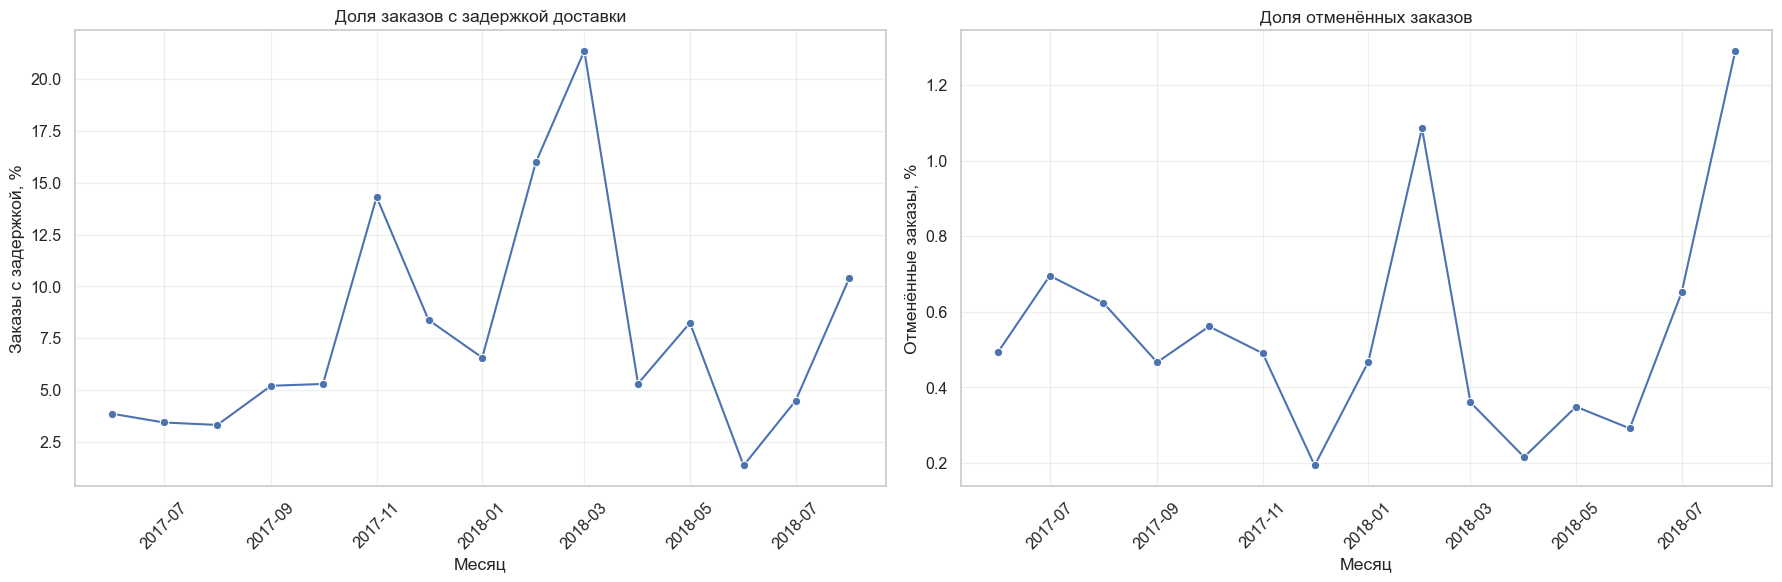

In [31]:
# Задержки доставки по месяцам
monthly_late_delivery = (
    delivered_from_june
    .groupby('order_month', as_index=False)
    .agg(
        delivered_orders=('order_id', 'nunique'),
        late_orders=('is_late', 'sum')
    )
)
monthly_late_delivery['late_orders_rate'] = (
    monthly_late_delivery['late_orders'] / monthly_late_delivery['delivered_orders']
)

# Отмены по месяцам
monthly_cancellations = (
    data_from_june_2017
    .groupby('order_month', as_index=False)
    .agg(
        total_orders=('order_id', 'nunique'),
        canceled_orders=('order_status', lambda x: (x == 'canceled').sum())
    )
)
monthly_cancellations['canceled_orders_rate'] = (
    monthly_cancellations['canceled_orders'] / monthly_cancellations['total_orders']
)

# Для графиков убираем неполные последние месяцы
monthly_late_delivery_plot = monthly_late_delivery[monthly_late_delivery['order_month'] <= '2018-08-01'].copy()
monthly_cancellations_plot = monthly_cancellations[monthly_cancellations['order_month'] <= '2018-08-01'].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=monthly_late_delivery_plot,
    x='order_month',
    y=monthly_late_delivery_plot['late_orders_rate'] * 100,
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Доля заказов с задержкой доставки')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Заказы с задержкой, %')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

sns.lineplot(
    data=monthly_cancellations_plot,
    x='order_month',
    y=monthly_cancellations_plot['canceled_orders_rate'] * 100,
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Доля отменённых заказов')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Отменённые заказы, %')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ICE

In [32]:
def get_impact_score(value):
    """Перевод значения метрики в Impact по шкале задания."""
    if value <= 50:
        return 1
    elif value <= 150:
        return 2
    elif value <= 350:
        return 3
    elif value <= 750:
        return 4
    elif value <= 1550:
        return 5
    elif value <= 3150:
        return 6
    elif value <= 6350:
        return 7
    elif value <= 12750:
        return 8
    elif value <= 25550:
        return 9
    elif value <= 51150:
        return 10
    else:
        return 10

hypotheses = pd.DataFrame({
    'hypothesis': [
        'Исправить баг в системе процессинга заказов',
        'Сократить время до отгрузки заказа',
        'Создать новый способ оплаты'
    ],
    'impact_metric_value': [
        impact_h1_metric,
        impact_h2_metric,
        impact_h3_metric
    ],
    'confidence': [8, 10, 5],
    'ease': [6, 4, 9]
})

hypotheses['impact'] = hypotheses['impact_metric_value'].apply(get_impact_score)
hypotheses['ICE'] = hypotheses['impact'] * hypotheses['confidence'] * hypotheses['ease']
hypotheses = hypotheses.sort_values('ICE', ascending=False).reset_index(drop=True)

display(hypotheses)

,hypothesis,impact_metric_value,confidence,ease,impact,ICE
0,Исправить баг в системе процессинга заказов,499.0000,8,6,4,192
1,Создать новый способ оплаты,407.3923,5,9,4,180
2,Сократить время до отгрузки заказа,36.7685,10,4,1,40


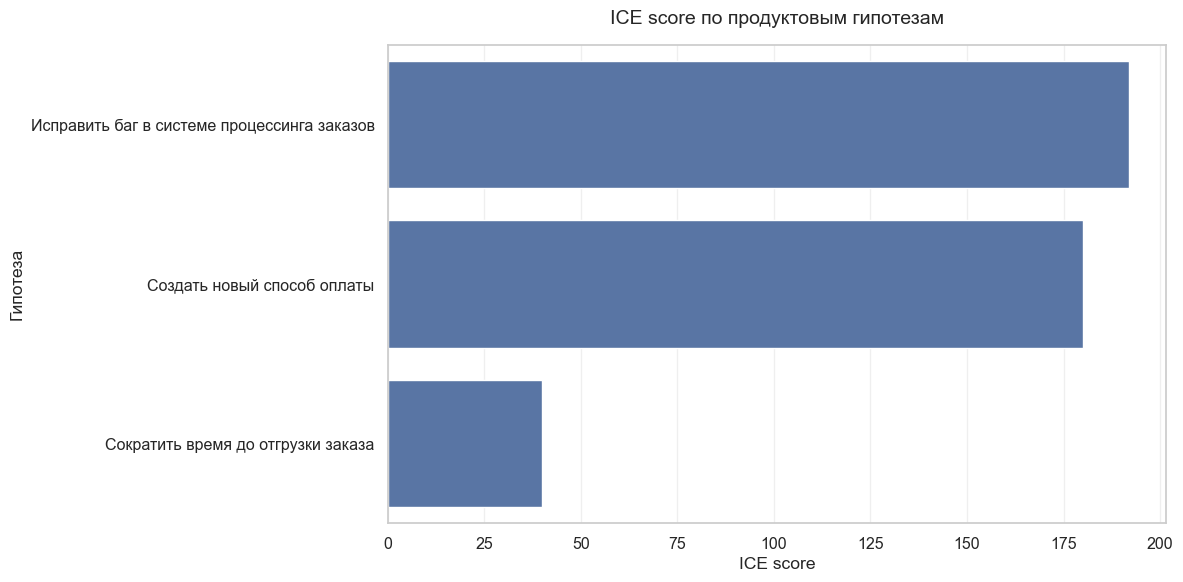

In [33]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=hypotheses,
    x='ICE',
    y='hypothesis'
)

plt.title('ICE score по продуктовым гипотезам', fontsize=14, pad=15)
plt.xlabel('ICE score')
plt.ylabel('Гипотеза')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод по задаче 4.** Формально по ICE наивысший приоритет получает гипотеза об **исправлении бага в системе процессинга заказов**. Её эффект наиболее прямой: отменённый заказ — это уже сформированный спрос, который не дошёл до успешной доставки.

При этом важно учитывать продуктовый контекст: доля отменённых заказов невелика, поэтому **это скорее операционный фикс** и способ уменьшить потери уже созданного спроса, а не стратегическое решение проблемы низкого retention. После такого исправления фокус всё равно должен оставаться на гипотезах, которые увеличивают повторные покупки и регулярную ценность продукта.

---
# Задача 5. Метрики для A/B-теста выбранной гипотезы

Выбранная гипотеза: **исправить баг в системе процессинга заказов**, чтобы уменьшить отмены и увеличить количество доставленных заказов.

Для A/B-теста нужны метрики разных типов: целевая, прокси и guardrail.

## 5.1. Целевая метрика

**Delivered Order Rate**

Формула:

`Delivered Order Rate = delivered orders / all orders`

Эта метрика показывает, выросла ли доля заказов, которые дошли до успешной доставки. Она напрямую связана с целью гипотезы: если отмен станет меньше, больше заказов должно переходить в статус `delivered`.

Дополнительно можно смотреть **GMV from delivered orders** — сумму продаж по доставленным заказам. Это показывает денежный эффект, но такая метрика более шумная: один дорогой заказ может сильно повлиять на результат.

## 5.2. Прокси-метрика

**Cancel Rate**

Формула:

`Cancel Rate = canceled orders / all created orders`

Эта метрика показывает, сработал ли механизм гипотезы. Если баг в процессинге действительно исправлен, доля отменённых заказов должна снизиться.

## 5.3. Guardrail-метрика

**Late Delivery Rate**

Формула:

`Late Delivery Rate = late delivered orders / delivered orders`

Где:

`late = order_delivered_customer_date > order_estimated_delivery_date`

Эта метрика нужна, чтобы проверить, что снижение отмен не достигается за счёт ухудшения клиентского опыта. Например, если система перестанет отменять проблемные заказы, но такие заказы начнут чаще приезжать с задержкой, это будет негативным эффектом.

In [34]:
# Исторический расчёт выбранных метрик как baseline для будущего A/B-теста
ab_baseline = orders_customers.copy()
ab_baseline['is_delivered'] = ab_baseline['order_status'] == 'delivered'
ab_baseline['is_canceled'] = ab_baseline['order_status'] == 'canceled'

# Для late delivery rate используем только delivered-заказы
ab_delivered = ab_baseline[ab_baseline['is_delivered']].copy()
ab_delivered['is_late'] = (
    ab_delivered['order_delivered_customer_date'] >
    ab_delivered['order_estimated_delivery_date']
)

baseline_metrics = pd.DataFrame({
    'metric': [
        'Delivered Order Rate',
        'Cancel Rate',
        'Late Delivery Rate'
    ],
    'value': [
        ab_baseline['is_delivered'].mean(),
        ab_baseline['is_canceled'].mean(),
        ab_delivered['is_late'].mean()
    ]
})

baseline_metrics['value_percent'] = baseline_metrics['value'] * 100

display(baseline_metrics)

,metric,value,value_percent
0,Delivered Order Rate,0.9702,97.0203
1,Cancel Rate,0.0063,0.6285
2,Late Delivery Rate,0.0811,8.1117


## Дополнительно: метрики для альтернативной гипотезы про новый способ оплаты

Если команда всё-таки выберет гипотезу про новый способ оплаты, набор метрик должен быть другим:

- **Целевая:** `Repeat Purchase Rate = repeat buyers / all buyers`, дополнительно `GMV from repeat orders`.
- **Прокси:** `Payment Success Rate = successful payments / payment attempts`. В текущем датасете этой метрики нет, её нужно собирать в продуктовой аналитике. Приближённо можно смотреть `Order Approval Rate = orders with order_approved_at / all created orders`.
- **Guardrail:** `Payment Error Rate`, `Cancel Rate`, `Time to Approval = order_approved_at - order_purchase_timestamp`.

Это важно, потому что новый способ оплаты может как увеличить повторные заказы, так и создать новые ошибки в оформлении.

---
# Выводы

1. Медианный retention 1-го месяца ниже 1%, поэтому маркетплейс в основном привлекает разовых покупателей.
2. Product/market fit по повторным заказам не подтверждается: retention curve не показывает устойчивого плато.
3. Для управления продуктом стоит отслеживать GMV, Monthly Buyers, Conversion to First Purchase, Repeat Purchase Rate и ARPPU.
4. По ICE формально побеждает гипотеза об исправлении бага в процессинге заказов, но это скорее операционное улучшение, чем стратегический драйвер PMF.
5. Для A/B-теста выбранной гипотезы основная метрика — Delivered Order Rate, прокси — Cancel Rate, guardrail — Late Delivery Rate.

Главная продуктовая рекомендация: не ограничиваться исправлением отмен. После операционных улучшений маркетплейсу нужно искать механики, которые создают регулярную ценность и повышают повторные покупки.

# Дополнительное исследование

In [ ]:
#1. География: топ штатов и городов

# Основной спрос сильно сконцентрирован в крупнейших городах и штата, особенно в SP и São Paulo. 
# Маркетплейсу стоит отдельно анализировать регионы-лидеры, 
# там уже есть сформированный спрос и потенциально ниже стоимость масштабирования.

In [38]:
top_states = (
    delivered
    .groupby('customer_state', as_index=False)
    .agg(
        orders=('order_id', 'nunique'),
        buyers=('customer_unique_id', 'nunique')
    )
    .sort_values('orders', ascending=False)
)

top_states.head(5)

,customer_state,orders,buyers
25,SP,40501,39156
18,RJ,12350,11917
10,MG,11354,11001
22,RS,5345,5168
17,PR,4923,4769


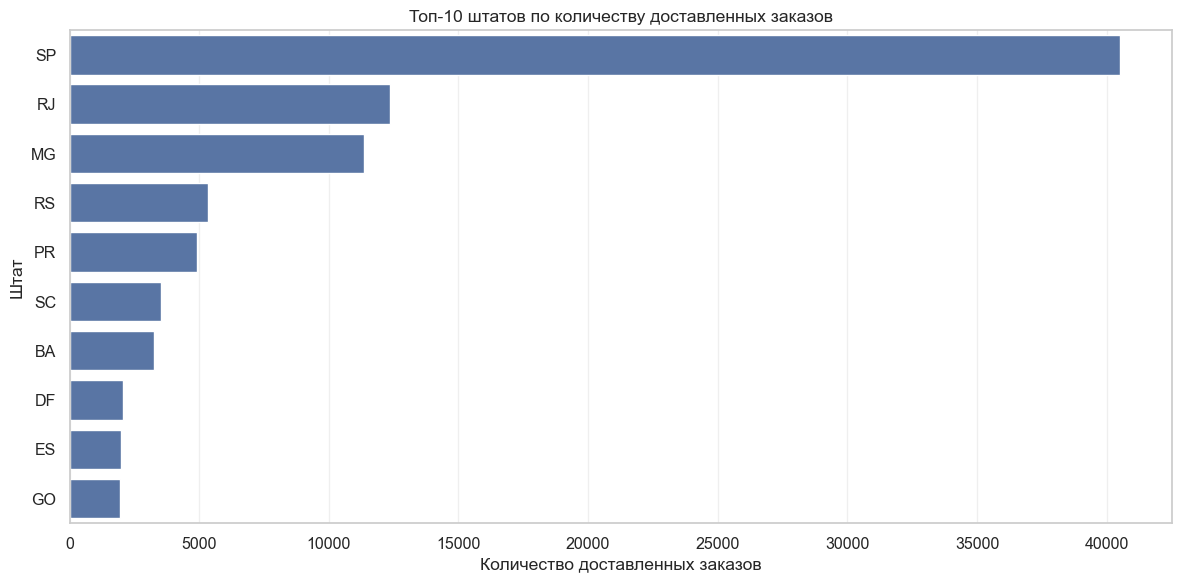

In [37]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_states.head(10),
    x='orders',
    y='customer_state'
)

plt.title('Топ-10 штатов по количеству доставленных заказов')
plt.xlabel('Количество доставленных заказов')
plt.ylabel('Штат')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
top_cities = (
    delivered
    .groupby(['customer_city', 'customer_state'], as_index=False)
    .agg(
        orders=('order_id', 'nunique'),
        buyers=('customer_unique_id', 'nunique')
    )
    .sort_values('orders', ascending=False)
)

top_cities.head(5)

,customer_city,customer_state,orders,buyers
3721,sao paulo,SP,15045,14528
3250,rio de janeiro,RJ,6601,6361
465,belo horizonte,MG,2697,2606
582,brasilia,DF,2071,2013
1179,curitiba,PR,1489,1434


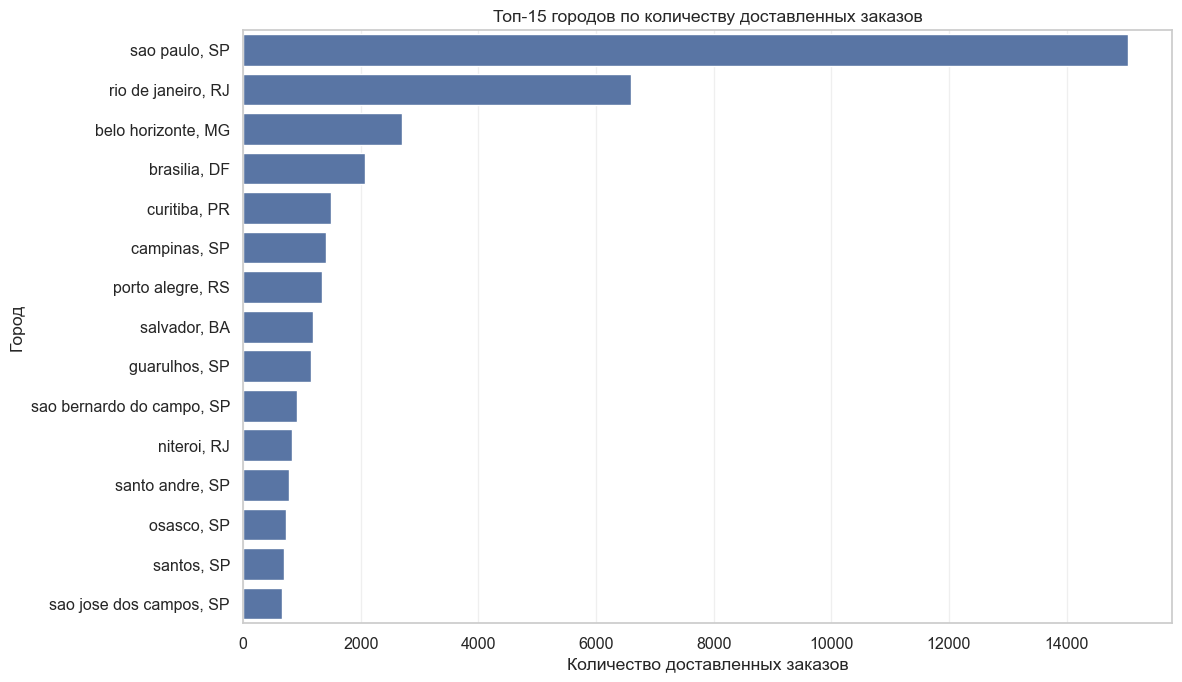

In [41]:
top_cities_plot = top_cities.head(15).copy()
top_cities_plot['city_state'] = (
    top_cities_plot['customer_city'] + ', ' + top_cities_plot['customer_state']
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_cities_plot,
    x='orders',
    y='city_state'
)

plt.title('Топ-15 городов по количеству доставленных заказов')
plt.xlabel('Количество доставленных заказов')
plt.ylabel('Город')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 2. Парные товары / заказы с несколькими позициями

# Большинство заказов содержит одну товарную позицию, но есть сегмент заказов с несколькими позициями. 
# Это потенциальная точка роста GMV: можно тестировать рекомендации, 
# комплекты товаров, блок “часто покупают вместе” и кросс-сейл механики.
# Заказы с несколькими товарными позициями имеют более высокий средний GMV. 
# Это подтверждает, что механики кросс-сейла и рекомендаций могут быть точкой роста выручки.

In [72]:
# считаем количество позиций в заказе:
order_items_count = (
    items_d
    .groupby('order_id', as_index=False)
    .agg(
        items_count=('order_item_id', 'count'),
        unique_products=('product_id', 'nunique')
    )
)

order_items_count.head()

,order_id,items_count,unique_products
0,00010242fe8c5a6d1ba2dd792cb16214,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,1
2,000229ec398224ef6ca0657da4fc703e,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1


In [73]:
orders_with_items = delivered.merge(
    order_items_count,
    on='order_id',
    how='left'
)
orders_with_items[['items_count', 'unique_products']].describe()

,items_count,unique_products
count,"96,478.0000","96,478.0000"
mean,1.1422,1.0385
std,0.5388,0.2279
min,1.0000,1.0000
25%,1.0000,1.0000
50%,1.0000,1.0000
75%,1.0000,1.0000
max,21.0000,8.0000


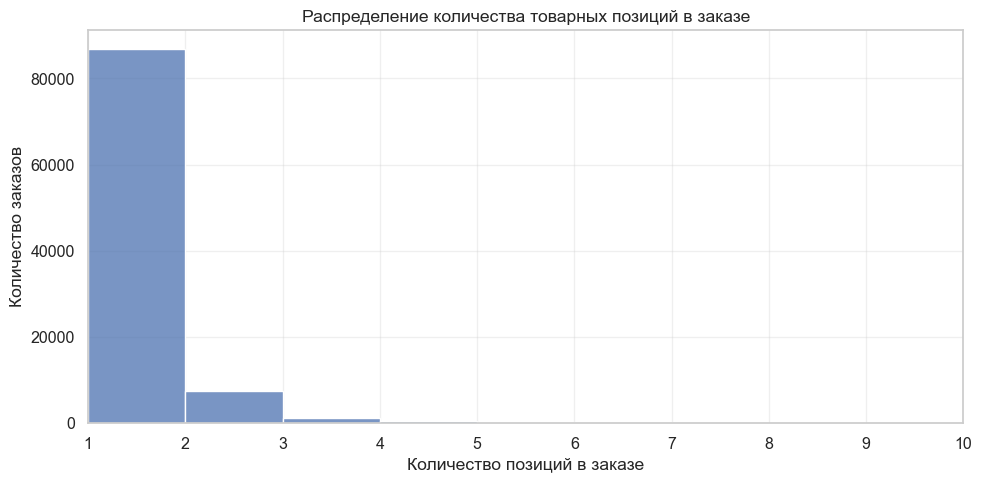

In [74]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=orders_with_items,
    x='items_count',
    bins=20
)

plt.title('Распределение количества товарных позиций в заказе')
plt.xlabel('Количество позиций в заказе')
plt.ylabel('Количество заказов')
plt.xlim(1, 10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
# Доля заказов с 2+ позициями:

multi_item_share = (orders_with_items['items_count'] > 1).mean()

print(f'Доля заказов с несколькими товарными позициями: {multi_item_share * 100:.2f}%')

Доля заказов с несколькими товарными позициями: 9.99%


In [ ]:
# Самые частые пары товаров

In [76]:
from itertools import combinations
from collections import Counter

# Берём заказы, где есть минимум 2 разных продукта
products_by_order = (
    items_d
    .groupby('order_id')['product_id']
    .apply(lambda x: sorted(set(x)))
)

product_pairs = []

for products in products_by_order:
    if len(products) >= 2:
        product_pairs.extend(combinations(products, 2))

pair_counts = Counter(product_pairs)

top_pairs = (
    pd.DataFrame(
        pair_counts.most_common(20),
        columns=['product_pair', 'orders_count']
    )
)

top_pairs['product_1'] = top_pairs['product_pair'].apply(lambda x: x[0])
top_pairs['product_2'] = top_pairs['product_pair'].apply(lambda x: x[1])

top_pairs['pair_label'] = (
    top_pairs['product_1'].str[:8] + ' + ' + top_pairs['product_2'].str[:8]
)

display(top_pairs[['product_1', 'product_2', 'orders_count']].head(10))

,product_1,product_2,orders_count
0,36f60d45225e60c7da4558b070ce4b60,e53e557d5a159f5aa2c5e995dfdf244b,34
1,35afc973633aaeb6b877ff57b2793310,99a4788cb24856965c36a24e339b6058,29
2,4fcb3d9a5f4871e8362dfedbdb02b064,f4f67ccaece962d013a4e1d7dc3a61f7,17
3,36f60d45225e60c7da4558b070ce4b60,3f14d740544f37ece8a9e7bc8349797e,12
4,389d119b48cf3043d311335e499d9c6b,422879e10f46682990de24d770e7f83d,11
5,389d119b48cf3043d311335e499d9c6b,53759a2ecddad2bb87a079a1f1519f73,9
6,368c6c730842d78016ad823897a372db,53759a2ecddad2bb87a079a1f1519f73,8
7,18486698933fbb64af6c0a255f7dd64c,dbb67791e405873b259e4656bf971246,7
8,422879e10f46682990de24d770e7f83d,53759a2ecddad2bb87a079a1f1519f73,7
9,060cb19345d90064d1015407193c233d,98d61056e0568ba048e5d78038790e77,6


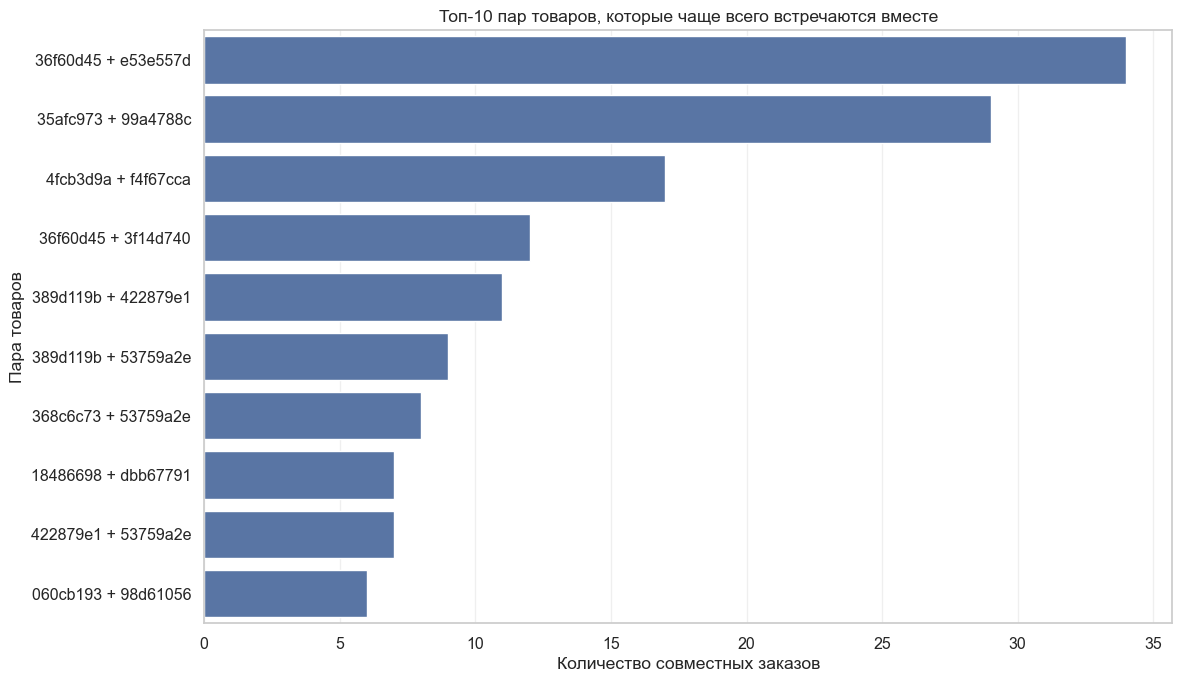

In [77]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_pairs.head(10),
    x='orders_count',
    y='pair_label'
)

plt.title('Топ-10 пар товаров, которые чаще всего встречаются вместе')
plt.xlabel('Количество совместных заказов')
plt.ylabel('Пара товаров')

plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Средний чек / AOV и заказы с несколькими товарами

In [70]:
order_gmv = (
    items_d
    .groupby('order_id', as_index=False)
    .agg(gmv=('price', 'sum'))
)

orders_value = delivered.merge(order_gmv, on='order_id', how='left')
orders_value = orders_value.merge(order_items_count, on='order_id', how='left')

orders_value['order_type'] = np.where(
    orders_value['items_count'] > 1,
    'multi-item order',
    'single-item order'
)

aov_by_order_type = (
    orders_value
    .groupby('order_type', as_index=False)
    .agg(
        orders=('order_id', 'nunique'),
        avg_gmv=('gmv', 'mean'),
        median_gmv=('gmv', 'median')
    )
)

display(aov_by_order_type)

,order_type,orders,avg_gmv,median_gmv
0,multi-item order,9635,203.2063,134.9700
1,single-item order,86843,129.7008,79.9000


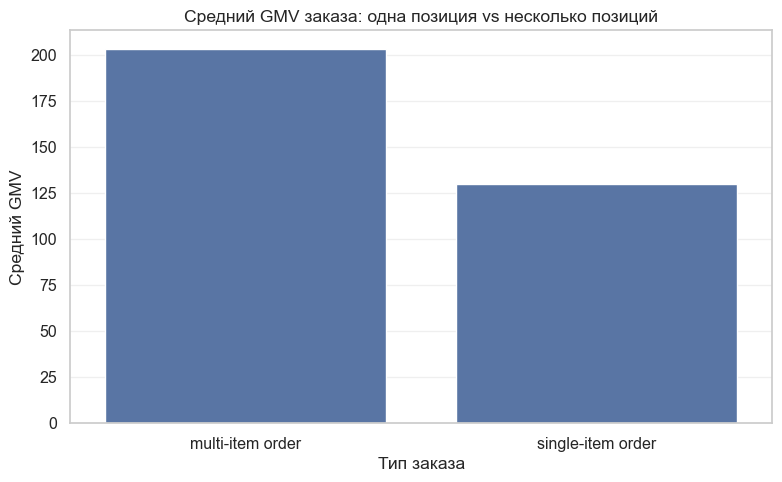

In [69]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=aov_by_order_type,
    x='order_type',
    y='avg_gmv'
)

plt.title('Средний GMV заказа: одна позиция vs несколько позиций')
plt.xlabel('Тип заказа')
plt.ylabel('Средний GMV')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Анализ возвращаемости среди всех покупателей и среди повторных покупателей

# Берем только доставленные заказы
delivered_orders = (
    orders
    .query("order_status == 'delivered'")
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
    .copy()
)

# Считаем количество заказов на каждого уникального пользователя
orders_per_user = (
    delivered_orders
    .groupby('customer_unique_id', as_index=False)
    .agg(orders_count=('order_id', 'nunique'))
)

# 1. Общая возвращаемость: доля пользователей, которые сделали 2+ заказа
all_buyers = orders_per_user['customer_unique_id'].nunique()
repeat_buyers = orders_per_user.query("orders_count >= 2")['customer_unique_id'].nunique()

overall_return_rate = repeat_buyers / all_buyers

# 2. Возвращаемость среди повторных покупателей:
# доля пользователей с 2+ заказами, которые сделали еще один заказ, то есть 3+
buyers_2_plus = orders_per_user.query("orders_count >= 2")['customer_unique_id'].nunique()
buyers_3_plus = orders_per_user.query("orders_count >= 3")['customer_unique_id'].nunique()

return_rate_after_repeat = buyers_3_plus / buyers_2_plus

# Во сколько раз возвращаемость выше
uplift = return_rate_after_repeat / overall_return_rate

return_comparison = pd.DataFrame({
    'segment': [
        'Все покупатели',
        'Покупатели с 2+ заказами'
    ],
    'return_rate': [
        overall_return_rate,
        return_rate_after_repeat
    ]
})

print(f"Общая возвращаемость: {overall_return_rate:.2%}")
print(f"Возвращаемость среди покупателей с 2+ заказами: {return_rate_after_repeat:.2%}")
print(f"Возвращаемость у покупателей с 2+ заказами выше в {uplift:.1f} раза")

return_comparison

Общая возвращаемость: 3.00%
Возвращаемость среди покупателей с 2+ заказами: 8.14%
Возвращаемость у покупателей с 2+ заказами выше в 2.7 раза


,segment,return_rate
0,Все покупатели,0.0300
1,Покупатели с 2+ заказами,0.0814


/var/folders/dl/sjp1n8kn10jd0y8qn19fbrz40000gn/T/ipykernel_4010/1469999134.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{y:.0%}' for y in ax.get_yticks()])


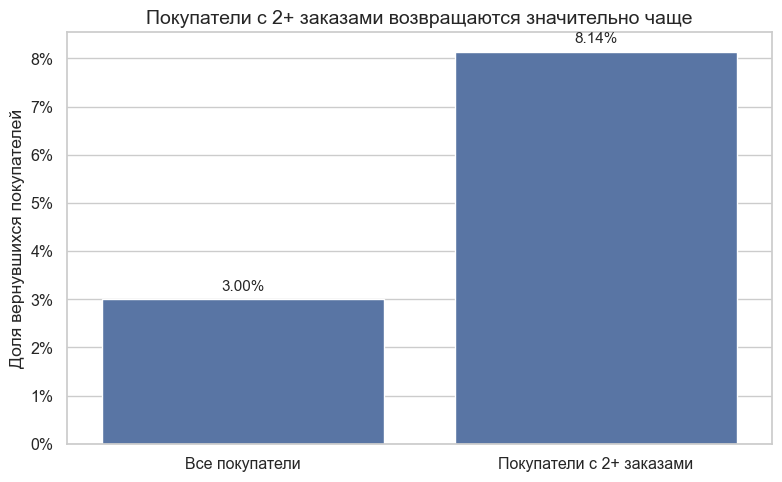

Вывод: покупатели, которые уже сделали 2+ заказа, возвращаются примерно в 2.7 раза чаще.


In [7]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=return_comparison,
    x='segment',
    y='return_rate'
)

plt.title('Покупатели с 2+ заказами возвращаются значительно чаще', fontsize=14)
plt.xlabel('')
plt.ylabel('Доля вернувшихся покупателей')

ax.set_yticklabels([f'{y:.0%}' for y in ax.get_yticks()])

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:.2%}' for v in return_comparison['return_rate']],
        padding=4,
        fontsize=11
    )

plt.tight_layout()
plt.show()

print(f'Вывод: покупатели, которые уже сделали 2+ заказа, возвращаются примерно в {uplift:.1f} раза чаще.')

In [ ]:
# 3. Стоимость доставки как барьер для покупки

# Для значительной части товаров доставка является существенным барьером для покупки, особенно в низком ценовом сегменте.
# 36.6% товаров — доставка более 30% от цены
# Даже если пользователь заинтересован в товаре, 
# итоговая цена с доставкой может снижать вероятность оформления заказа и повторной покупки.

In [78]:
# Считаем долю доставки от цены товара
items_d['freight_to_price_ratio'] = items_d['freight_value'] / items_d['price']

# Убираем возможные аномалии с нулевой или отрицательной ценой
items_delivery = items_d[items_d['price'] > 0].copy()

delivery_barriers = pd.DataFrame({
    'metric': [
        'Доставка > 30% от цены товара',
        'Доставка > 50% от цены товара',
        'Доставка дороже товара'
    ],
    'share': [
        (items_delivery['freight_to_price_ratio'] > 0.30).mean(),
        (items_delivery['freight_to_price_ratio'] > 0.50).mean(),
        (items_delivery['freight_to_price_ratio'] > 1.00).mean()
    ]
})

delivery_barriers['share_percent'] = delivery_barriers['share'] * 100

display(delivery_barriers)

,metric,share,share_percent
0,Доставка > 30% от цены товара,0.3656,36.5601
1,Доставка > 50% от цены товара,0.1681,16.8140
2,Доставка дороже товара,0.0366,3.6609


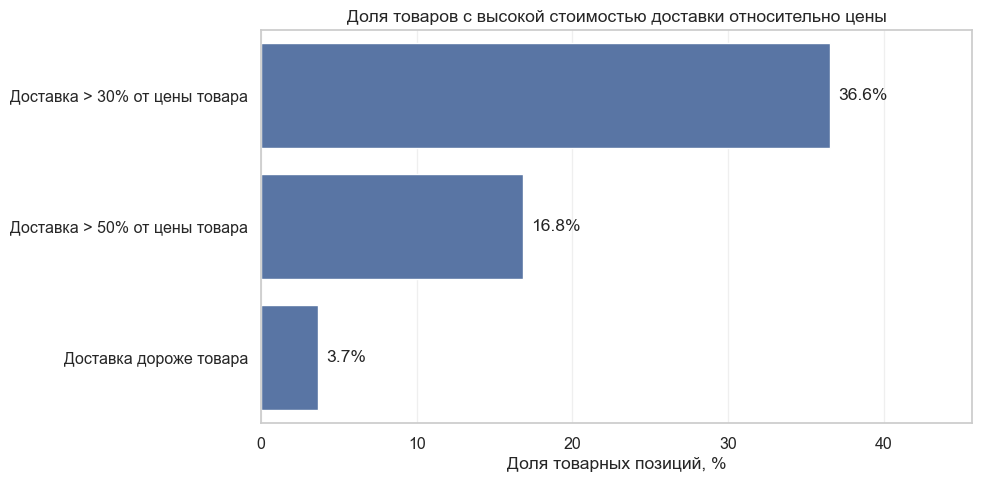

In [79]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=delivery_barriers,
    x='share_percent',
    y='metric'
)

plt.title('Доля товаров с высокой стоимостью доставки относительно цены')
plt.xlabel('Доля товарных позиций, %')
plt.ylabel('')

for i, value in enumerate(delivery_barriers['share_percent']):
    plt.text(
        value + 0.5,
        i,
        f'{value:.1f}%',
        va='center'
    )

plt.xlim(0, max(delivery_barriers['share_percent']) * 1.25)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

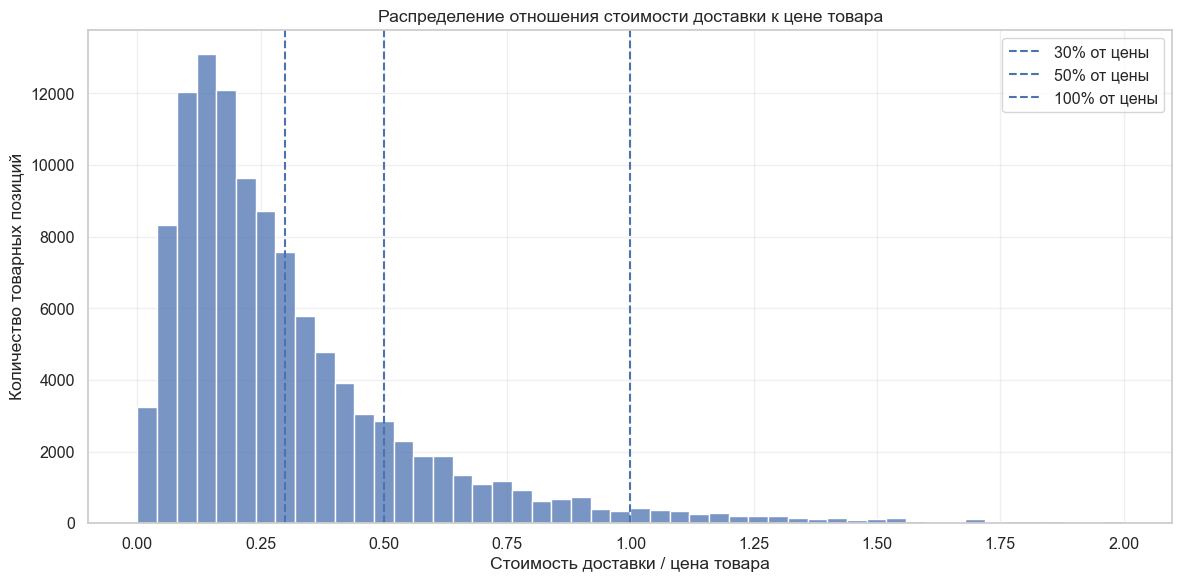

In [80]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=items_delivery[items_delivery['freight_to_price_ratio'] <= 2],
    x='freight_to_price_ratio',
    bins=50
)

plt.axvline(0.3, linestyle='--', label='30% от цены')
plt.axvline(0.5, linestyle='--', label='50% от цены')
plt.axvline(1.0, linestyle='--', label='100% от цены')

plt.title('Распределение отношения стоимости доставки к цене товара')
plt.xlabel('Стоимость доставки / цена товара')
plt.ylabel('Количество товарных позиций')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ключевые инсайты

1. Продукт практически не удерживает пользователей - месячный retention ниже 1%
    - почти все пользователи делают один заказ
2. Выручка зависит от привлечения новых пользователей
    - отсутствует модель роста через LTV
3. Каталог не имеет выраженных товаров-локомотивов
    - важны рекомендации и навигация
4. Доставка является скрытым барьером, у 37% товаров доставка более 30% от цены
    - особенно для дешевых товаров
5. Есть потенциал для cross-sell
    - выявлены устойчивые товарные пары


## Рекомендации

### Retention (приоритет)
* промокоды на второй заказ
* email/push-коммуникации через 7–14 дней
* персонализированные рекомендации

Увеличение среднего чека
* бесплатная доставка от суммы
* наборы товаров (бандлы)
* механики “добавьте еще”

Cross-sell
* блок “часто покупают вместе”
* рекомендации после покупки
* клиенты с multi-item заказами возвращаются почти в 3 раза чаще.

Работа с доставкой
* оптимизация логистики
* субсидирование доставки для дешевых товаров
* прозрачность стоимости доставки

География
* усиление маркетинга в ключевых городах
* тестирование логистических гипотез в регионах
